# Student Performance Analysis
### End-to-End Data Science Pipeline — Data Science Mini Project

**Course:** Data Science (4th Semester) — Department of CS, UET Peshawar

---

## 1. Problem Definition

**Problem Statement:** Schools currently identify struggling students only *after* final exams, when it is too late to intervene. We need a data-driven way to identify at-risk students early in the academic year.

**Business Objective:** Enable school administrators and teachers to proactively target academic support (tutoring, counselling, parental engagement) at students who are likely to fail, improving overall pass rates and reducing dropouts.

**Machine Learning Task:** **Binary classification** — predict whether a student will **pass** (final grade G3 ≥ 10) or **fail** (G3 < 10) using only demographic, social and school-related attributes available *before* exams (grade columns G1, G2, G3 are excluded from features to prevent data leakage).

## 2. Data Collection

**Source:** [UCI Machine Learning Repository — Student Performance Dataset](https://archive.ics.uci.edu/dataset/320/student+performance) (Cortez & Silva, 2008).

We combine the Mathematics (395 records) and Portuguese (649 records) course files into a single dataset of **1,044 records × 33 attributes** (plus a `subject` indicator), satisfying the ≥1,000 records and ≥10 features requirements.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")
RANDOM_STATE = 42
PASS_THRESHOLD = 10

In [2]:
# --- Self-contained data loading (no external data/ folder needed) ---
# The two UCI CSV files are embedded below as base64 so this single .ipynb
# can run on its own, on any machine, with no other files required.
import io, base64

_STUDENT_MAT_B64 = "..."
_STUDENT_POR_B64 = "..."

mat = pd.read_csv(io.StringIO(base64.b64decode(_STUDENT_MAT_B64).decode("utf-8")), sep=";")
por = pd.read_csv(io.StringIO(base64.b64decode(_STUDENT_POR_B64).decode("utf-8")), sep=";")
mat["subject"] = "math"
por["subject"] = "portuguese"
df = pd.concat([mat, por], ignore_index=True)
for c in ("G1", "G2", "G3"):
    df[c] = pd.to_numeric(df[c], errors="coerce")

print(f"Dataset shape: {df.shape}")
df.head()


Dataset shape: (1044, 34)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3,subject
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,3,4,1,1,3,6,5,6,6,math
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,3,3,1,1,3,4,5,5,6,math
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,3,2,2,3,3,10,7,8,10,math
3,GP,F,15,U,GT3,T,4,2,health,services,...,2,2,1,1,5,2,15,14,15,math
4,GP,F,16,U,GT3,T,3,3,other,other,...,3,2,1,2,5,4,6,10,10,math


### Data Dictionary (key attributes)

| Attribute | Description | Type |
|---|---|---|
| school | Student's school (GP / MS) | Binary |
| sex | Gender (F / M) | Binary |
| age | Age (15–22) | Numeric |
| address | Urban / Rural | Binary |
| Medu / Fedu | Mother's / Father's education (0–4) | Ordinal |
| Mjob / Fjob | Mother's / Father's job | Nominal |
| traveltime | Home-to-school travel time (1–4) | Ordinal |
| studytime | Weekly study time (1–4) | Ordinal |
| failures | Past class failures (0–4) | Numeric |
| schoolsup / famsup / paid | Extra school / family / paid support | Binary |
| activities / internet / romantic | Extracurriculars / internet access / relationship | Binary |
| famrel / freetime / goout | Family relations / free time / going out (1–5) | Ordinal |
| Dalc / Walc | Workday / weekend alcohol consumption (1–5) | Ordinal |
| health | Current health status (1–5) | Ordinal |
| absences | School absences (0–93) | Numeric |
| G1 / G2 / G3 | Period 1 / 2 / final grade (0–20) | Numeric |
| subject | Course (math / portuguese) | Binary |

## 3. Data Quality Assessment

In [3]:
print("Missing values per column (non-zero only):")
missing = df.isna().sum()
print(missing[missing > 0] if missing.sum() else "  None")

print(f"\nDuplicate rows: {df.duplicated().sum()}")
print("\nData types:")
print(df.dtypes.value_counts())

# Outlier detection with the IQR rule
num_cols = df.select_dtypes("number").columns
outliers = {}
for c in num_cols:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    n = ((df[c] < q1 - 1.5 * iqr) | (df[c] > q3 + 1.5 * iqr)).sum()
    if n:
        outliers[c] = int(n)
print("\nOutliers (IQR rule):", outliers)

Missing values per column (non-zero only):
  None

Duplicate rows: 0

Data types:
str      18
int64    16
Name: count, dtype: int64

Outliers (IQR rule): {'age': 2, 'traveltime': 24, 'studytime': 62, 'failures': 183, 'famrel': 77, 'freetime': 64, 'Dalc': 52, 'absences': 54, 'G1': 1, 'G2': 20, 'G3': 54}


In [4]:
# Cleaning: drop duplicates, cap extreme absences, create the target
df = df.drop_duplicates().reset_index(drop=True)
df["absences"] = df["absences"].clip(upper=df["absences"].quantile(0.99))
df["passed"] = (df["G3"] >= PASS_THRESHOLD).astype(int)

print(f"Records after cleaning: {len(df)}")
print(f"Class balance:\n{df['passed'].value_counts()}")
print(f"Pass rate: {df['passed'].mean():.2%}")
df.describe().T.head(12)

Records after cleaning: 1044
Class balance:
passed
1    814
0    230
Name: count, dtype: int64
Pass rate: 77.97%


,count,mean,std,min,25%,50%,75%,max
age,1044.0,16.726054,1.239975,15.0,16.0,17.0,18.0,22.0
Medu,1044.0,2.603448,1.124907,0.0,2.0,3.0,4.0,4.0
Fedu,1044.0,2.387931,1.099938,0.0,1.0,2.0,3.0,4.0
traveltime,1044.0,1.522989,0.731727,1.0,1.0,1.0,2.0,4.0
studytime,1044.0,1.970307,0.834353,1.0,1.0,2.0,2.0,4.0
failures,1044.0,0.264368,0.656142,0.0,0.0,0.0,0.0,3.0
famrel,1044.0,3.935824,0.933401,1.0,4.0,4.0,5.0,5.0
freetime,1044.0,3.201149,1.031507,1.0,3.0,3.0,4.0,5.0
goout,1044.0,3.156130,1.152575,1.0,2.0,3.0,4.0,5.0
Dalc,1044.0,1.494253,0.911714,1.0,1.0,1.0,2.0,5.0


## 4. Exploratory Data Analysis

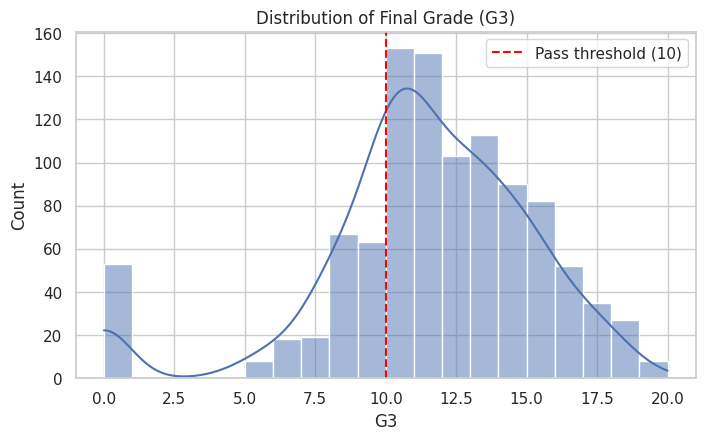

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.5))
sns.histplot(df, x="G3", bins=20, kde=True, ax=ax)
ax.axvline(10, color="red", linestyle="--", label="Pass threshold (10)")
ax.set_title("Distribution of Final Grade (G3)")
ax.legend()
plt.show()

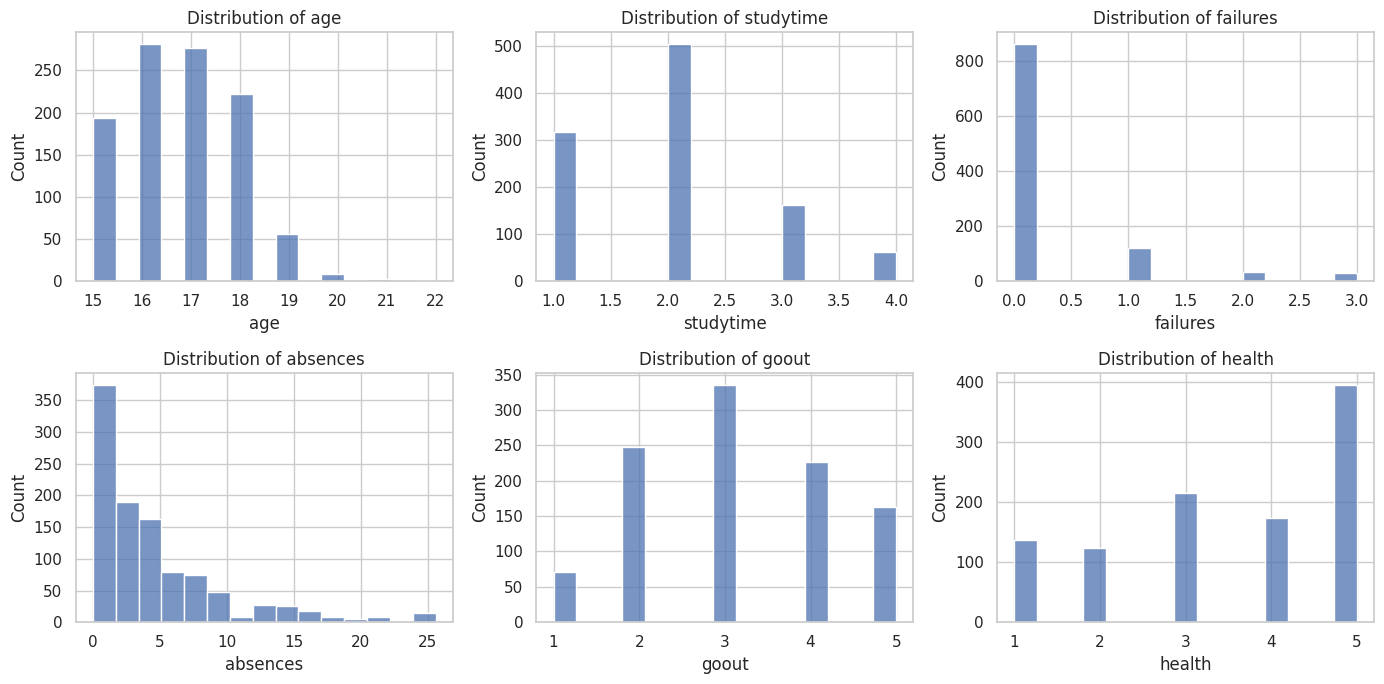

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
for ax, c in zip(axes.flat, ["age", "studytime", "failures", "absences", "goout", "health"]):
    sns.histplot(df, x=c, ax=ax, bins=15)
    ax.set_title(f"Distribution of {c}")
plt.tight_layout()
plt.show()

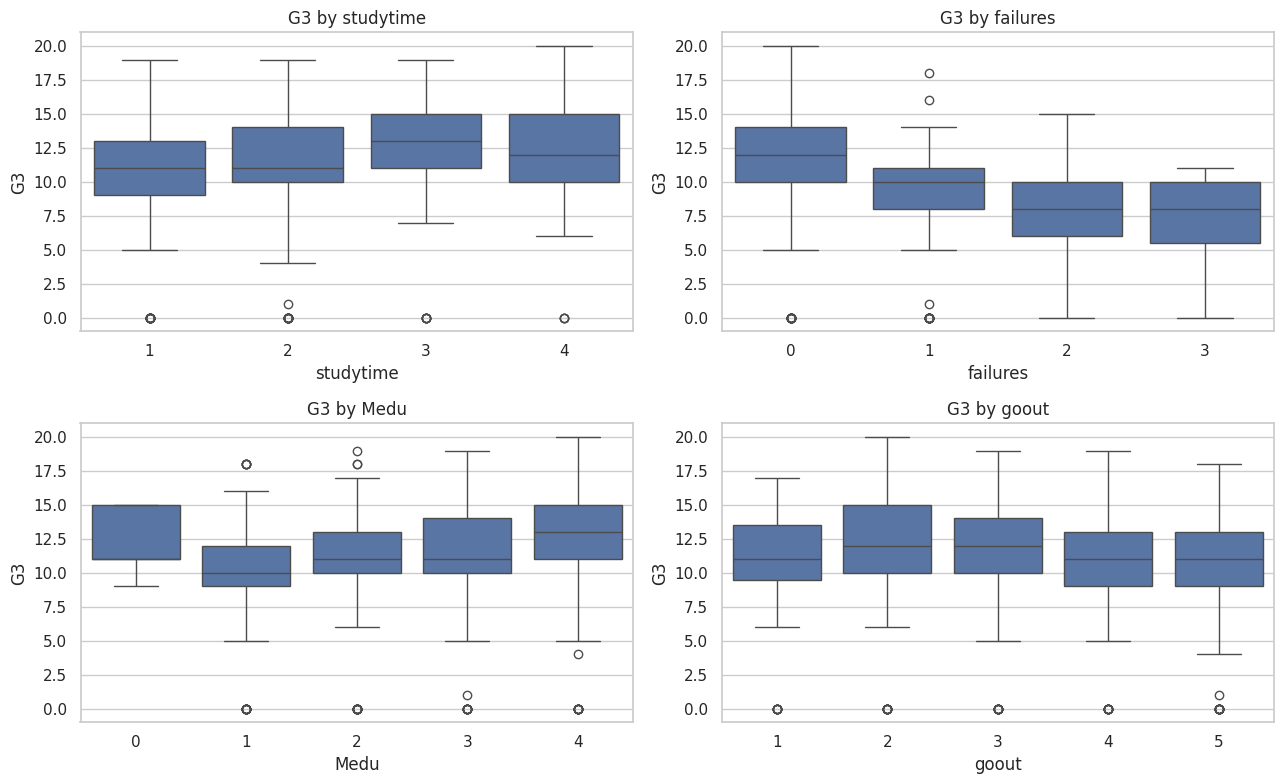

In [7]:
fig, axes = plt.subplots(2, 2, figsize=(13, 8))
for ax, c in zip(axes.flat, ["studytime", "failures", "Medu", "goout"]):
    sns.boxplot(df, x=c, y="G3", ax=ax)
    ax.set_title(f"G3 by {c}")
plt.tight_layout()
plt.show()

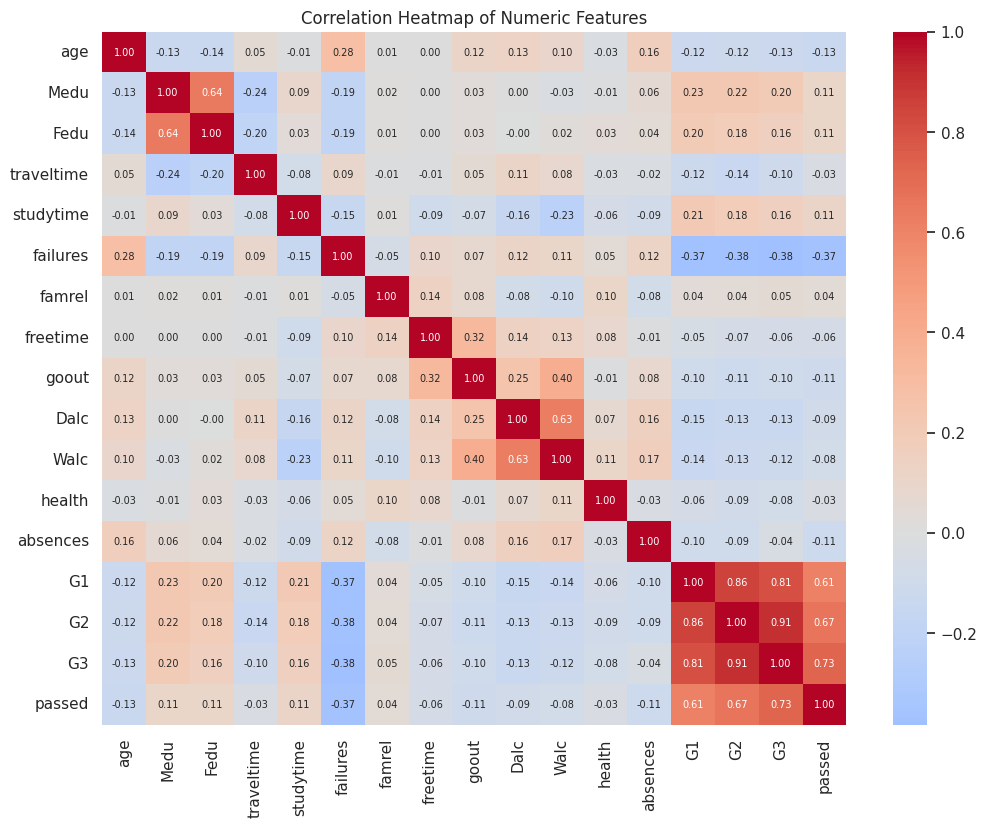

In [8]:
fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(df.select_dtypes("number").corr(), cmap="coolwarm", center=0,
            annot=True, fmt=".2f", annot_kws={"size": 7}, ax=ax)
ax.set_title("Correlation Heatmap of Numeric Features")
plt.show()

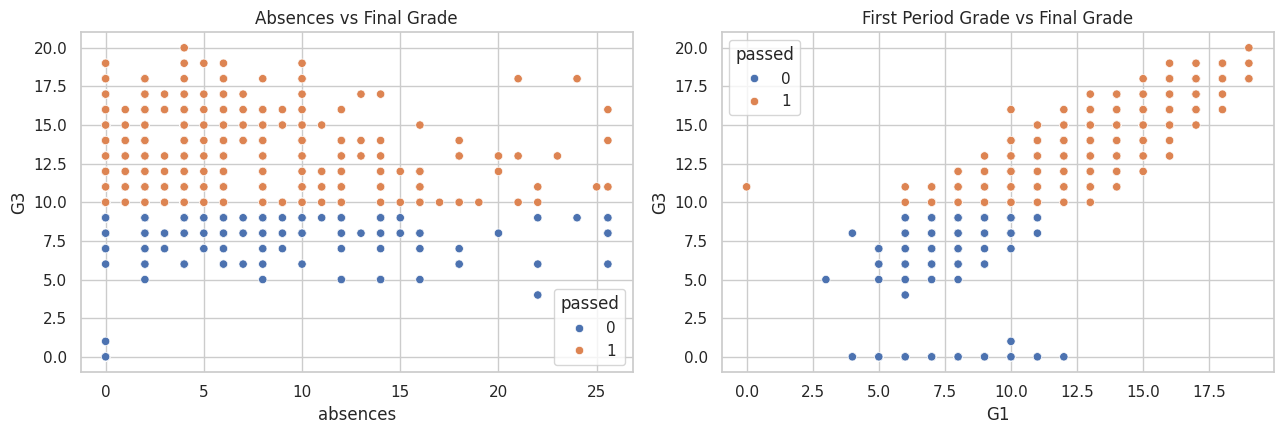

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
sns.scatterplot(df, x="absences", y="G3", hue="passed", ax=axes[0])
axes[0].set_title("Absences vs Final Grade")
sns.scatterplot(df, x="G1", y="G3", hue="passed", ax=axes[1])
axes[1].set_title("First Period Grade vs Final Grade")
plt.tight_layout()
plt.show()

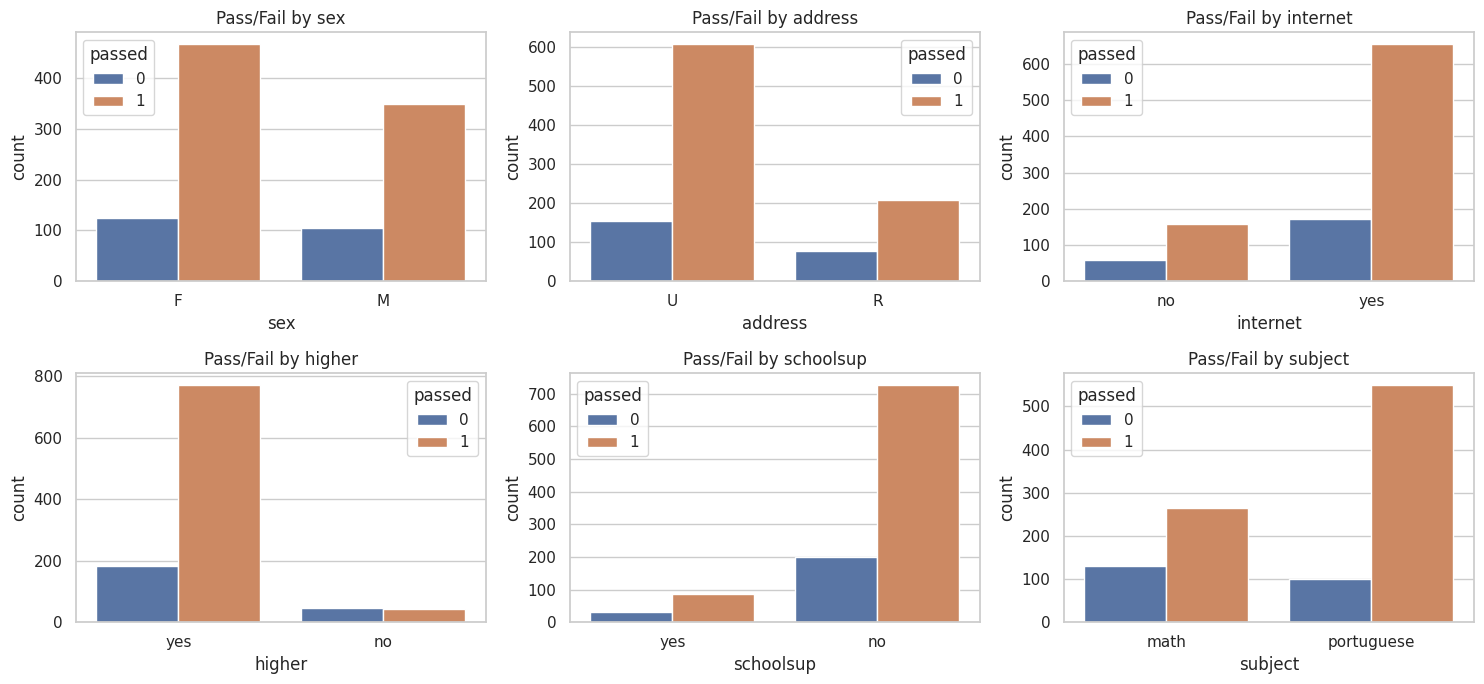

In [10]:
fig, axes = plt.subplots(2, 3, figsize=(15, 7))
for ax, c in zip(axes.flat, ["sex", "address", "internet", "higher", "schoolsup", "subject"]):
    sns.countplot(df, x=c, hue="passed", ax=ax)
    ax.set_title(f"Pass/Fail by {c}")
plt.tight_layout()
plt.show()

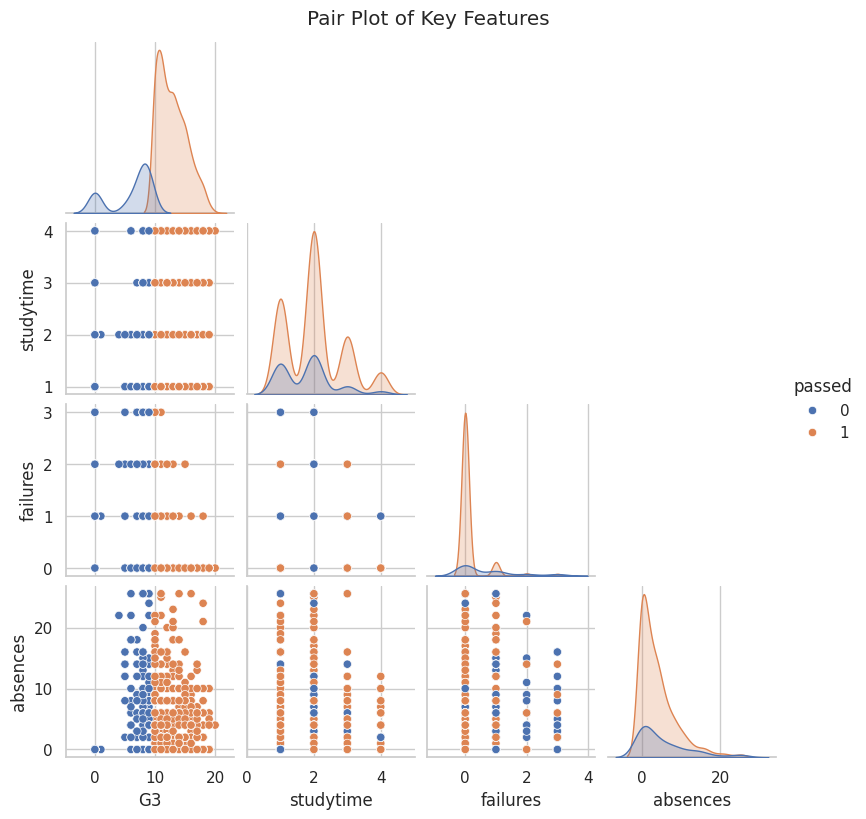

In [11]:
g = sns.pairplot(df[["G3", "studytime", "failures", "absences", "passed"]],
                 hue="passed", corner=True, height=2.0)
g.figure.suptitle("Pair Plot of Key Features", y=1.02)
plt.show()

**Key EDA findings**

- The final grade G3 is roughly normal around 10–12 with a spike of zero grades (dropouts); ~78% of students pass.
- `failures` shows the strongest negative relationship with G3 — students with past failures are far more likely to fail again.
- Higher parental education (`Medu`/`Fedu`), more `studytime` and the ambition to pursue `higher` education are associated with passing.
- More `goout` (going out) and alcohol consumption relate to lower grades; `absences` is heavily right-skewed.
- G1 and G2 are extremely correlated with G3 (r > 0.8) — confirming they must be **excluded** to avoid leakage in an early-warning model.

## 5. Feature Engineering

We apply **feature creation**, **encoding** (label + one-hot) and **scaling** (standardisation), plus a **log transformation** for the skewed `absences`.

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

dfe = df.copy()

# --- Feature creation ---
dfe["parent_edu_avg"] = (dfe["Medu"] + dfe["Fedu"]) / 2
dfe["alcohol_index"] = (5 * dfe["Dalc"] + 2 * dfe["Walc"]) / 7
dfe["support_count"] = ((dfe["schoolsup"] == "yes").astype(int)
                        + (dfe["famsup"] == "yes").astype(int)
                        + (dfe["paid"] == "yes").astype(int))
dfe["study_social_ratio"] = dfe["studytime"] / (dfe["goout"] + 1)
dfe["age_group"] = pd.cut(dfe["age"], bins=[14, 16, 18, 23], labels=[0, 1, 2]).astype(int)
dfe["log_absences"] = np.log1p(dfe["absences"])   # log transformation

# --- Encoding ---
binary_maps = {
    "school": {"GP": 0, "MS": 1}, "sex": {"F": 0, "M": 1},
    "address": {"U": 0, "R": 1}, "famsize": {"LE3": 0, "GT3": 1},
    "Pstatus": {"T": 0, "A": 1}, "subject": {"math": 0, "portuguese": 1},
}
for c in ["schoolsup", "famsup", "paid", "activities", "nursery",
          "higher", "internet", "romantic"]:
    binary_maps[c] = {"no": 0, "yes": 1}
for c, m in binary_maps.items():
    dfe[c] = dfe[c].map(m)                          # label encoding
dfe = pd.get_dummies(dfe, columns=["Mjob", "Fjob", "reason", "guardian"],
                     drop_first=True, dtype=int)    # one-hot encoding

# --- Split & scale (grades dropped: leakage prevention) ---
y = dfe["passed"]
X = dfe.drop(columns=["G1", "G2", "G3", "passed"])
feature_names = list(X.columns)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=feature_names, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=feature_names, index=X_test.index)

print(f"Feature matrix: {len(feature_names)} features | Train {X_train.shape} | Test {X_test.shape}")

Feature matrix: 46 features | Train (835, 46) | Test (209, 46)


## 6. Feature Selection

We apply **four** methods across all three families (two required):

1. **Filter** — Correlation analysis & Chi-Square test
2. **Wrapper** — Recursive Feature Elimination (RFE, logistic regression)
3. **Embedded** — Random Forest feature importance

The final feature set contains every feature selected by **at least two** methods.

In [13]:
from sklearn.feature_selection import RFE, SelectKBest, chi2
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import MinMaxScaler

K = 15

# 1a. Correlation (filter)
corr = X_train.apply(lambda c: c.corr(y_train)).abs().sort_values(ascending=False)
corr_feats = list(corr.head(K).index)

# 1b. Chi-Square (filter) — requires non-negative input
chi_sel = SelectKBest(chi2, k=K).fit(MinMaxScaler().fit_transform(X_train), y_train)
chi_scores = pd.Series(chi_sel.scores_, index=X_train.columns).sort_values(ascending=False)
chi_feats = list(chi_scores.head(K).index)

# 2. RFE (wrapper)
rfe = RFE(LogisticRegression(max_iter=2000, random_state=RANDOM_STATE),
          n_features_to_select=K).fit(X_train, y_train)
rfe_feats = list(X_train.columns[rfe.support_])

# 3. Tree importance (embedded)
rf_sel = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE).fit(X_train, y_train)
imp = pd.Series(rf_sel.feature_importances_, index=X_train.columns).sort_values(ascending=False)
tree_feats = list(imp.head(K).index)

# Vote: keep features chosen by >= 2 methods
sets = [set(corr_feats), set(chi_feats), set(rfe_feats), set(tree_feats)]
votes = pd.Series({f: sum(f in s for s in sets) for f in feature_names}).sort_values(ascending=False)
final_features = list(votes[votes >= 2].index)

print(f"Correlation top-{K}: {corr_feats}\n")
print(f"Chi-Square top-{K}: {chi_feats}\n")
print(f"RFE selected: {rfe_feats}\n")
print(f"Tree-importance top-{K}: {tree_feats}\n")
print(f"FINAL feature set ({len(final_features)}): {final_features}")

Correlation top-15: ['failures', 'higher', 'subject', 'parent_edu_avg', 'Medu', 'Fedu', 'study_social_ratio', 'school', 'age_group', 'absences', 'age', 'goout', 'studytime', 'guardian_other', 'alcohol_index']

Chi-Square top-15: ['failures', 'subject', 'school', 'guardian_other', 'reason_reputation', 'paid', 'higher', 'address', 'age_group', 'absences', 'schoolsup', 'Dalc', 'romantic', 'studytime', 'alcohol_index']

RFE selected: ['school', 'age', 'failures', 'schoolsup', 'higher', 'goout', 'absences', 'subject', 'parent_edu_avg', 'support_count', 'age_group', 'log_absences', 'Mjob_services', 'Fjob_other', 'guardian_mother']

Tree-importance top-15: ['failures', 'log_absences', 'absences', 'subject', 'study_social_ratio', 'alcohol_index', 'parent_edu_avg', 'goout', 'freetime', 'age', 'higher', 'health', 'support_count', 'famrel', 'Walc']

FINAL feature set (16): ['failures', 'higher', 'absences', 'subject', 'age', 'school', 'goout', 'age_group', 'parent_edu_avg', 'alcohol_index', 'supp

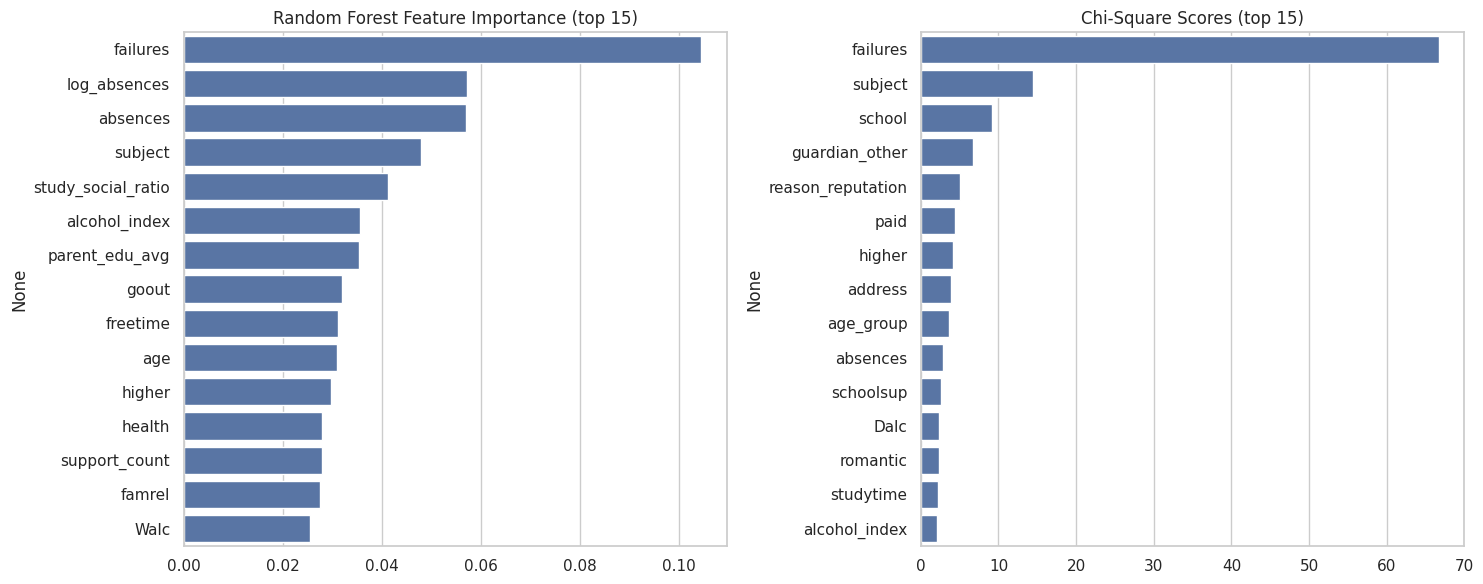

In [14]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.barplot(x=imp.head(15).values, y=imp.head(15).index, ax=axes[0])
axes[0].set_title("Random Forest Feature Importance (top 15)")
sns.barplot(x=chi_scores.head(15).values, y=chi_scores.head(15).index, ax=axes[1])
axes[1].set_title("Chi-Square Scores (top 15)")
plt.tight_layout()
plt.show()

X_train_sel, X_test_sel = X_train[final_features], X_test[final_features]

**Justification:** The voting approach combines the strengths of all families — filter methods capture univariate signal, RFE captures multivariate interactions, and tree importance captures non-linear effects. Features such as `failures`, `higher`, `absences`/`log_absences`, `studytime`, `goout` and the engineered `parent_edu_avg`, `alcohol_index`, `support_count`, `study_social_ratio` are consistently selected across methods.

## 7. Baseline Model — Logistic Regression

In [15]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, RocCurveDisplay)

def evaluate(name, model, X_te=None, y_te=None):
    X_te = X_test_sel if X_te is None else X_te
    y_te = y_test if y_te is None else y_te
    y_pred = model.predict(X_te)
    y_prob = model.predict_proba(X_te)[:, 1]
    return {"model": name,
            "accuracy": accuracy_score(y_te, y_pred),
            "precision": precision_score(y_te, y_pred),
            "recall": recall_score(y_te, y_pred),
            "f1": f1_score(y_te, y_pred),
            "roc_auc": roc_auc_score(y_te, y_prob)}

results = []
baseline = LogisticRegression(max_iter=2000, random_state=RANDOM_STATE)
baseline.fit(X_train_sel, y_train)
results.append(evaluate("Logistic Regression (baseline)", baseline))

print(classification_report(y_test, baseline.predict(X_test_sel),
                            target_names=["Fail", "Pass"]))

              precision    recall  f1-score   support

        Fail       0.59      0.22      0.32        46
        Pass       0.81      0.96      0.88       163

    accuracy                           0.79       209
   macro avg       0.70      0.59      0.60       209
weighted avg       0.76      0.79      0.76       209



## 8. Advanced Models — Random Forest, Gradient Boosting, SVM

In [16]:
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.svm import SVC

advanced = {
    "Random Forest": RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE),
    "Gradient Boosting": GradientBoostingClassifier(random_state=RANDOM_STATE),
    "SVM (RBF)": SVC(probability=True, random_state=RANDOM_STATE),
}
for name, model in advanced.items():
    model.fit(X_train_sel, y_train)
    results.append(evaluate(name, model))

pd.DataFrame(results).round(4)

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (baseline),0.7943,0.8125,0.9571,0.8789,0.7147
1,Random Forest,0.7895,0.8182,0.9387,0.8743,0.7236
2,Gradient Boosting,0.7943,0.8226,0.9387,0.8768,0.7507
3,SVM (RBF),0.7943,0.8158,0.9509,0.8782,0.7446


## 9. Hyperparameter Tuning — GridSearchCV (Random Forest)

In [17]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "n_estimators": [200, 400],
    "max_depth": [None, 8, 14],
    "min_samples_split": [2, 5, 10],
    "max_features": ["sqrt", 0.5],
}
grid = GridSearchCV(RandomForestClassifier(random_state=RANDOM_STATE),
                    param_grid, cv=5, scoring="f1", n_jobs=-1)
grid.fit(X_train_sel, y_train)
best_rf = grid.best_estimator_
results.append(evaluate("Random Forest (tuned)", best_rf))

print(f"Parameters tested: {param_grid}")
print(f"Best parameters:   {grid.best_params_}")
print(f"Best CV F1:        {grid.best_score_:.4f}")
rf_default = next(r for r in results if r["model"] == "Random Forest")
rf_tuned = results[-1]
print(f"Test ROC AUC: {rf_default['roc_auc']:.4f} (default) -> {rf_tuned['roc_auc']:.4f} (tuned)")

Parameters tested: {'n_estimators': [200, 400], 'max_depth': [None, 8, 14], 'min_samples_split': [2, 5, 10], 'max_features': ['sqrt', 0.5]}
Best parameters:   {'max_depth': 8, 'max_features': 'sqrt', 'min_samples_split': 10, 'n_estimators': 400}
Best CV F1:        0.8894
Test ROC AUC: 0.7236 (default) -> 0.7331 (tuned)


## 10. Bonus — Dimensionality Reduction with PCA

Components retaining 95% variance: 12 (from 16 features)
Accuracy before PCA: 0.7895 | after PCA: 0.8038


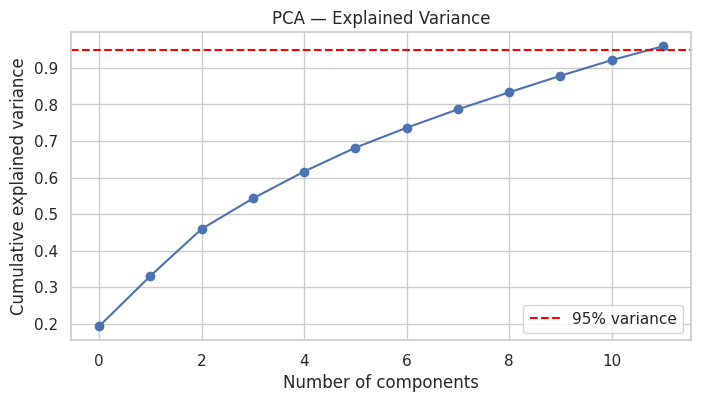

In [18]:
from sklearn.decomposition import PCA

pca = PCA(n_components=0.95, random_state=RANDOM_STATE)
X_train_pca = pca.fit_transform(X_train_sel)
X_test_pca = pca.transform(X_test_sel)

rf_pca = RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE)
rf_pca.fit(X_train_pca, y_train)
pca_res = evaluate("Random Forest + PCA", rf_pca, X_test_pca, y_test)
results.append(pca_res)

print(f"Components retaining 95% variance: {pca.n_components_} (from {X_train_sel.shape[1]} features)")
print(f"Accuracy before PCA: {rf_default['accuracy']:.4f} | after PCA: {pca_res['accuracy']:.4f}")

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(np.cumsum(pca.explained_variance_ratio_), marker="o")
ax.axhline(0.95, color="red", linestyle="--", label="95% variance")
ax.set_xlabel("Number of components")
ax.set_ylabel("Cumulative explained variance")
ax.set_title("PCA — Explained Variance")
ax.legend()
plt.show()

## 11. Model Evaluation & Comparison

,model,accuracy,precision,recall,f1,roc_auc
0,Logistic Regression (baseline),0.7943,0.8125,0.9571,0.8789,0.7147
1,Random Forest,0.7895,0.8182,0.9387,0.8743,0.7236
2,Gradient Boosting,0.7943,0.8226,0.9387,0.8768,0.7507
3,SVM (RBF),0.7943,0.8158,0.9509,0.8782,0.7446
4,Random Forest (tuned),0.7847,0.8105,0.9448,0.8725,0.7331
5,Random Forest + PCA,0.8038,0.8211,0.9571,0.8839,0.7231


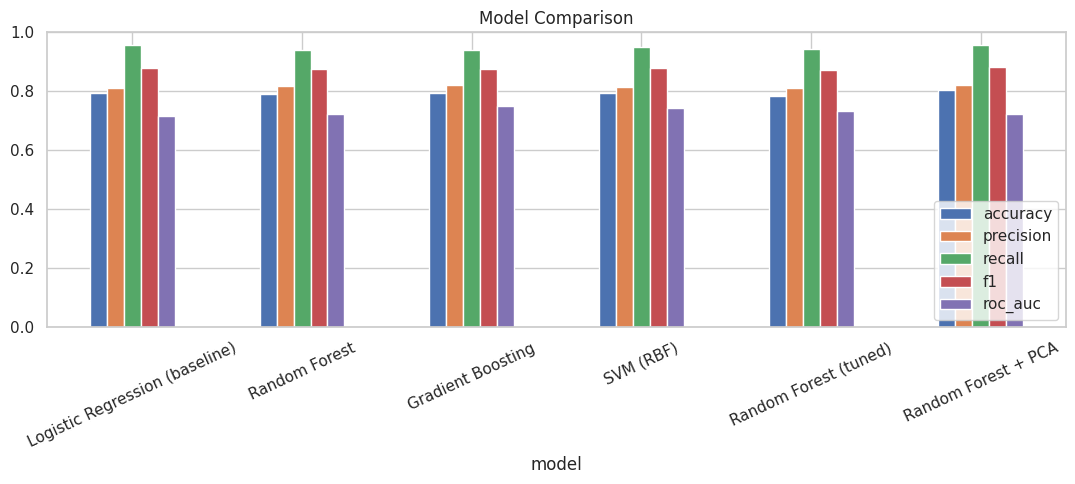

In [19]:
results_df = pd.DataFrame(results).round(4)
display(results_df)

fig, ax = plt.subplots(figsize=(11, 5))
results_df.set_index("model")[["accuracy", "precision", "recall", "f1", "roc_auc"]] \
    .plot.bar(ax=ax, rot=25)
ax.set_title("Model Comparison")
ax.set_ylim(0, 1)
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

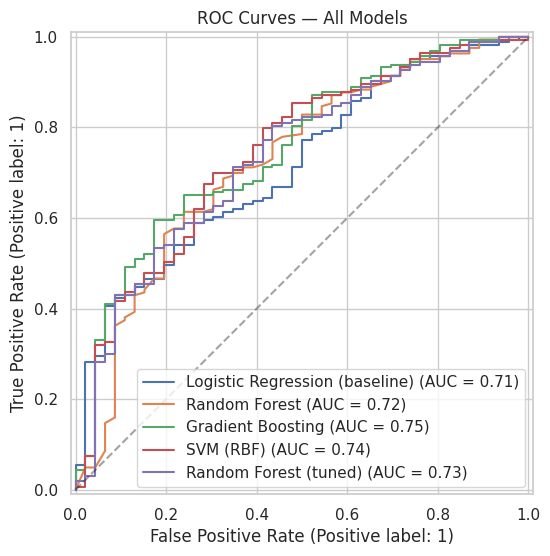

In [20]:
fig, ax = plt.subplots(figsize=(8, 6))
for name, model in {"Logistic Regression (baseline)": baseline, **advanced,
                    "Random Forest (tuned)": best_rf}.items():
    RocCurveDisplay.from_estimator(model, X_test_sel, y_test, name=name, ax=ax)
ax.plot([0, 1], [0, 1], "k--", alpha=0.4)
ax.set_title("ROC Curves — All Models")
plt.show()

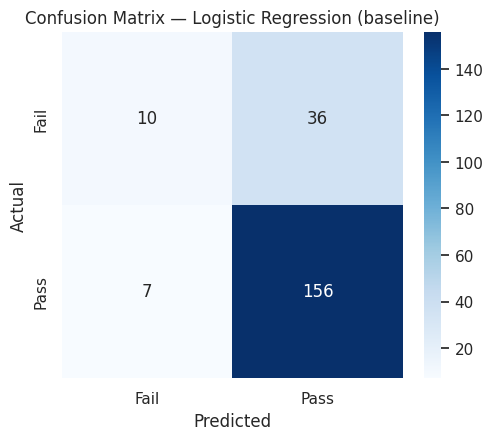

Best model by F1: Logistic Regression (baseline)


In [21]:
best_name = results_df.drop(results_df[results_df.model == "Random Forest + PCA"].index) \
    .sort_values("f1", ascending=False).iloc[0]["model"]
model_lookup = {"Logistic Regression (baseline)": baseline, **advanced,
                "Random Forest (tuned)": best_rf}
best_model = model_lookup[best_name]

cm = confusion_matrix(y_test, best_model.predict(X_test_sel))
fig, ax = plt.subplots(figsize=(5.5, 4.5))
sns.heatmap(pd.DataFrame(cm, index=["Fail", "Pass"], columns=["Fail", "Pass"]),
            annot=True, fmt="d", cmap="Blues", ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.show()
print(f"Best model by F1: {best_name}")

## 12. Business Insights & Conclusions

**Key drivers of student failure** (consistent across all feature-selection methods):

1. **Past failures** — the single strongest predictor; students who failed before need immediate intervention.
2. **No ambition for higher education** — strongly associated with failing; career counselling may help.
3. **High absences** — attendance monitoring should trigger early alerts.
4. **Low parental education** — students from these households benefit most from school-provided support.
5. **Frequent going out / higher alcohol consumption** — social-behavioural counselling opportunities.
6. **Low study time relative to social time** — study-skills workshops are actionable.

**Recommendations for the school:**

- Deploy the model at the start of the year to flag the ~22% highest-risk students for tutoring programmes.
- Because the model favours **recall on the Pass class**, pair it with human review for flagged students (false alarms are cheaper than missed at-risk students).
- Collect richer early-year data (attendance streaks, assignment scores) to improve fail-class recall in future iterations.

**Limitations:** dataset is from two Portuguese schools (2008) — retraining on local data is required before deployment; class imbalance (78/22) limits fail-class recall; without grade history the achievable accuracy ceiling is naturally lower, which is the honest trade-off of a genuinely *early* warning system.

## References

1. Cortez, P., & Silva, A. (2008). *Using Data Mining to Predict Secondary School Student Performance.* Proceedings of 5th FUture BUsiness TEChnology Conference (FUBUTEC 2008).
2. UCI Machine Learning Repository: Student Performance Data Set. https://archive.ics.uci.edu/dataset/320/student+performance
3. Pedregosa et al. (2011). *Scikit-learn: Machine Learning in Python.* JMLR 12.
4. Waskom, M. (2021). *seaborn: statistical data visualization.* JOSS 6(60).